<a href="https://colab.research.google.com/github/alex-bolshunov/Plant-Disease-Detection/blob/main/pca_plot_plants.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [101]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder
from matplotlib.lines import Line2D

In [102]:
LBL = "label"

In [103]:
!curl "https://raw.githubusercontent.com/alex-bolshunov/Plant-Disease-Detection/refs/heads/main/data/plants_resampled.csv" -o plants.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 11.7M  100 11.7M    0     0  17.7M      0 --:--:-- --:--:-- --:--:-- 17.7M


In [104]:
df = pd.read_csv("plants.csv")

In [105]:
#encode lables
encoder = LabelEncoder()

df.loc[:, LBL] = encoder.fit_transform(df.loc[:, LBL])

# Retrieve mapping
label_mapping = dict(zip(range(len(encoder.classes_)), encoder.classes_))

In [106]:
scaler = StandardScaler()

X, true_labels = scaler.fit_transform(df.drop(LBL, axis = 1)), df.loc[:, LBL].to_numpy().astype("int")

In [107]:
n_components = 3 #4

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

In [108]:
custom_colors = { 0: "#1f77b4",
                  1: "#2ca02c",
                  2: "#d62728" }

In [109]:
text_to_label = lambda text: " ".join([word.capitalize() for word in text.split("_")])

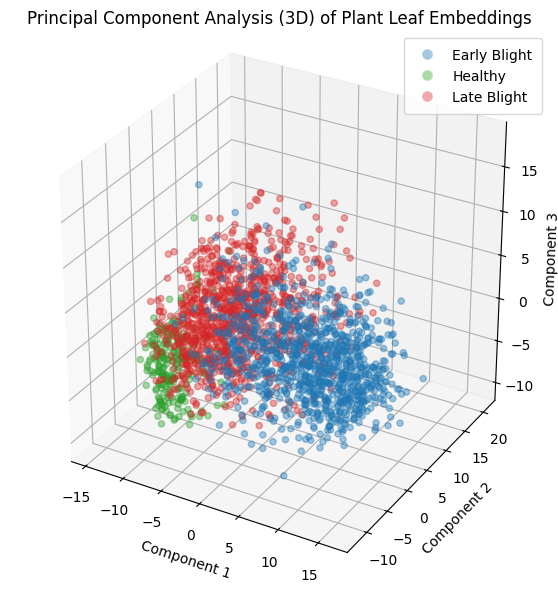

In [114]:
alpha = 0.4
markersize = 8
factor = 10
legend_elements = []

# scales = np.exp(X_pca)
# min_comp = np.min(scales)
# max_comp = np.max(scales)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

for label in sorted(set(true_labels)):
    idx = (true_labels == label)
    # ax.scatter(X_pca[idx, 0], X_pca[idx, 1], X_pca[idx, 2], s = scales[idx, 3] * factor, c=custom_colors[label], zorder = 5, alpha = alpha)
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], X_pca[idx, 2], c=custom_colors[label], zorder = 5, alpha = alpha)
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor = custom_colors[label], label=text_to_label(label_mapping[label]), markersize=markersize, alpha = alpha)
    )
ax.set_title("Principal Component Analysis (3D) of Plant Leaf Embeddings")
ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")
ax.set_zlabel("Component 3")
ax.set_box_aspect([1,1,1.02])

# legend_elements += [
#     Line2D([0], [0], marker='o', color='w',markerfacecolor = 'black', label=f'Component 4 min: {round(min_comp,2)}', markersize= min_comp * factor * 5, alpha = alpha),
#     Line2D([0], [0], marker='o', color='w',markerfacecolor = 'black', label=f'Component 4 max: {round(max_comp,2)}', markersize= max_comp * 0.6, alpha = alpha)
# ]

plt.grid(alpha = 0.5, zorder = 1)
plt.legend(handles=legend_elements, borderpad = 0.7)
plt.show()